In [1]:
#Import packages
#---------------------------------------
import sys
import os
import glob
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import matplotlib
import kedm
import warnings
import gc
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#Import your modules
#---------------------------------------
import CCM as cfn
import proc_functions as pfn

sys.path.insert(0, os.path.expanduser('~/Documents/admin_tools'))
from admin_tools import admin_functions as adfn

# Define paths
#----------------------------------------------------------------------
code = '~/Documents/empirical_dynamic_modelling'
data = '/snl/scratch25/dburrows/CCM'

%load_ext autoreload
sys.version

Kokkos::OpenMP::initialize WARNING: OMP_PROC_BIND environment variable not set
  In general, for best performance with OpenMP 4.0 or better set OMP_PROC_BIND=spread and OMP_PLACES=threads
  For best performance with OpenMP 3.1 set OMP_PROC_BIND=true
  For unit testing set OMP_PROC_BIND=false



'3.7.4 (default, Aug 13 2019, 20:35:49) \n[GCC 7.3.0]'

In [ ]:
# Generate stats on n CCMs - compare across filtering - decide on 1 (delete rest) 
# If smooth is best, optimise and add simplex E estimates

# Estimate convergence after kEDM

In [4]:
#group data
#================
#group by sample
xmap_l = np.asarray([os.path.basename(i) for i in np.sort(glob.glob(data + '/*xmap*'))])

import re
bln = xmap_l[[bool(re.search(r'(BLN|PTZ05)', i)) for i in xmap_l]]
ptz20 = xmap_l[[bool(re.search(r'(PTZ20)', i)) for i in xmap_l]]

#unique sample list 
unq_l = np.append(np.unique(np.asarray([re.search(r'^(.*?_run-01)', i).group(1) for i in bln])),
          np.unique(np.asarray([''.join(re.search(r'^(.*?_run-01)(.{4})', i).groups()) for i in ptz20])))

In [9]:
%autoreload
#estimate convergence
#======================

#parameters
n_int = 3 #expected interval files
int_l=[1.2, 1.4, 1.8] #expected intervals - make sure numbers are complete as in string! 
# -0.2 - i.e. allow a single negative value with <20% of the mean positive increase, to be convergent
ratio_val = -0.2 

curr = unq_l[0]
curr_l = glob.glob(f'{data}/{curr}*xmap*')

og, mask, conv_arr = pfn.conv_check(curr_l=curr_l, n_int=n_int, int_l = int_l, ratio_val=ratio_val)

In [ ]:
#size check
load = np.load(interval_l[0])
load1 = np.load(interval_l[1])
load2 = np.load(interval_l[2])
load3 = np.load(interval_l[3])


#check memory RAM usage of loading directly
print(f'{adfn.ram_gb(load)*4} GB')

In [9]:
#group load
#===============
#assert size match and interval check
assert(sum(pd.Series(curr_l).str.contains('interval')) == n_int), 'some interval files missing'
assert(sum(pd.Series(curr_l).str.contains('run-01_trace_CCMxmap')) == 1), 'missing complete xmap'
assert(sum(pd.Series(curr_l).str.contains('|'.join([f'-{str(i)}_' for i in int_l]))) == n_int), 'incorrect interval lengths'
assert(len(np.unique(curr_l)) == n_int + 1), 'some interval file lengths repeated'

#sort interval files in ascending length order
interval_l = np.sort(list(np.asarray(curr_l)[pd.Series(curr_l).str.contains('interval')]))
intervals = np.array([float(re.search(r'interval-([\d.]+)_trace', f).group(1)) for f in interval_l])
# Get sorted indices and reorder filenames accordingly
sorted_files = interval_l[np.argsort(intervals)]

#construct dictionary
conv_arr = []
conv_arr.append(np.ravel(np.load(np.asarray(curr_l)[pd.Series(curr_l).str.contains('run-01_trace_CCMxmap')][0])))
#array is constructed with full, and then decreasing time intervals
for x,s in enumerate(sorted_files):
    conv_arr.append(np.ravel(np.load(s)))
conv_arr=np.array(conv_arr)

#assert matrix size
assert all(t.shape == conv_arr[0].shape for t in conv_arr), "Not all tuples are the same"

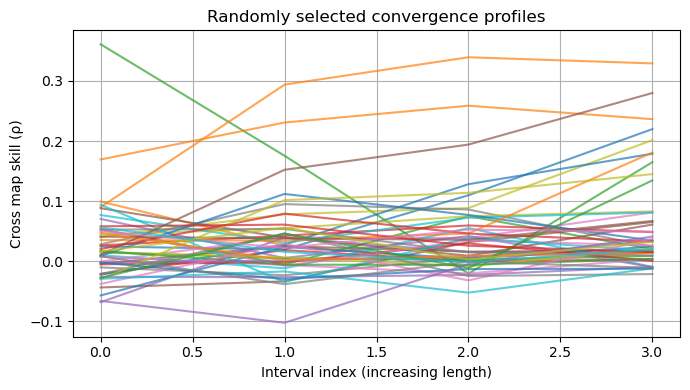

In [29]:
%autoreload
#visualise some exampes
pfn.plot_random_convergence_profiles(conv_arr, n=50, seed=None)

In [10]:
#look for approx monotonicity
#==============================

#look for convergence ->NB if you increase number of intervals this needs changing!!!
#====================================================================
diffs = np.diff(conv_arr , axis=0)*-1 #+ive diffs mean increasing from small->larger interval
sums = (diffs > 0).sum(axis=0) #how many +ive steps are there
monotonic_bool = sums > 2 #identify complete monotonic 

partial_bool = sums == 2 #identify 2/3 monotonic
partialzero_bool = (partial_bool) & ((diffs == 0).sum(axis=0) > 0) #2/3 monotonic and 1 at 0

#check to see what ratio of -ive to mean+ive is good
partial_only = diffs[:,(partial_bool) & (~partialzero_bool)] #diffs with partially monotonic and 1 negative value
po_ind = np.argwhere((partial_bool) & (~partialzero_bool))[:,0] # indeces of partial_only cells

arr = partial_only.copy()
arr[arr < 0] = np.nan                # mask negatives directly in the array (in-place)
mean_pos = np.nanmean(arr, axis=0)  # mean across rows, ignoring NaNs

row_indices = (partial_only < 0).argmax(axis=0)
po_neg_values = partial_only[row_indices, np.arange(partial_only.shape[1])] #returns values of all negative in po

ratio=po_neg_values/mean_pos #ratio is ratio of negative / mean pos

pm_ind = po_ind[ratio>ratio_val] #indeces in diffs of cells that pass the 20% threshold and are partially monotonic

partialpass_bool = np.zeros(diffs.shape[1], dtype=bool)
partialpass_bool[pm_ind] = True #2/3 monotonic and 1 <20% of mean pos


#get final bool of all passing cells
conv_bool = partialpass_bool | monotonic_bool | partialzero_bool
og = np.load(np.asarray(curr_l)[pd.Series(curr_l).str.contains('run-01_trace_CCMxmap')][0])
mask = conv_bool.reshape(og.shape)
conv_arr = conv_arr.reshape(tuple(np.append(4,og.shape)))

# #remove large unneeded variables
del conv_bool, partialpass_bool, pm_ind, ratio, po_neg_values, mean_pos, arr, po_ind, partial_only, partialzero_bool, partial_bool, monotonic_bool, sums, diffs
gc.collect()


8

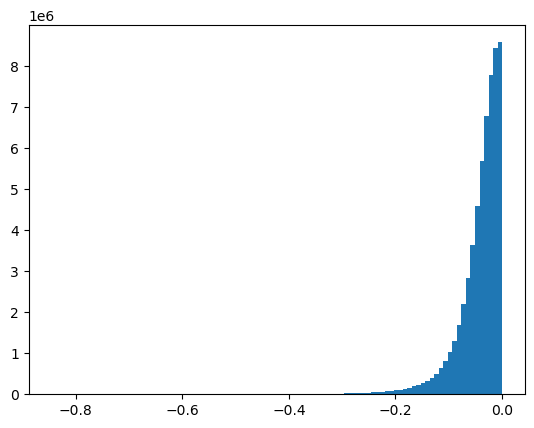

In [61]:
#visualise degree of slight negativity that exists in partially monotonic
plt.hist(po_neg_values, bins=100)
plt.show()

In [ ]:
#parameters
n_int = 3 #expected interval files
int_l=[1.2, 1.4, 1.8] #expected intervals - make sure numbers are complete as in string! 
# -0.2 - i.e. allow a single negative value with <20% of the mean positive increase, to be convergent
ratio_val = -0.2 

curr = unq_l[0]
curr_l = glob.glob(f'{data}/{curr}*xmap*')
curr_l

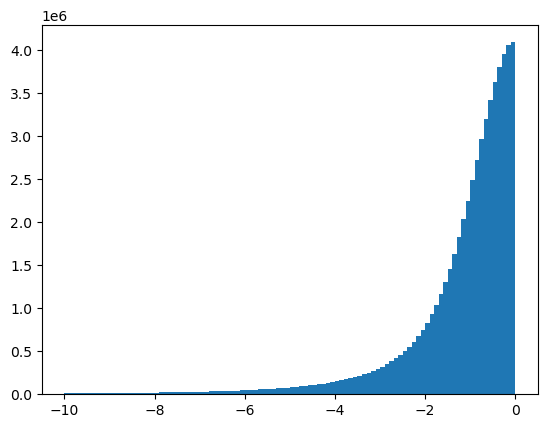

In [63]:
#visualise ratio of negative / mean_pos
plt.hist(ratio, bins=100, range=(-10,0))
plt.show()

# Convergence statistics

In [8]:
%autoreload
#Compute fraction of cells that converge, and mean CCM in convergent cells
#==========================================================
from tqdm import tqdm

#parameters
n_int = 3 #expected interval files
int_l=[1.2, 1.4, 1.8] #expected intervals - make sure numbers are complete as in string! 
# -0.2 - i.e. allow a single negative value with <20% of the mean positive increase, to be convergent
ratio_val = -0.2 

results = []
# Loop through each unique base name
for curr in tqdm(unq_l, desc='Processing CCM files'):
    curr_l = glob.glob(f'{data}/{curr}*xmap*')

    og, mask, conv_arr = pfn.conv_check(curr_l=curr_l, n_int=n_int, int_l=int_l, ratio_val=ratio_val)
    conv_frac = np.ravel(mask).sum() / mask.size
    mean = np.mean(og[mask])
    med = np.median(og[mask])
    std = np.std(og[mask])

    results.append({
        "name": curr,
        "converged_fraction": conv_frac,
        "mean_CCM": mean,
        "median_CCM": med,
        "std_CCM": std
    })

results_df = pd.DataFrame(results)
results_df.to_csv(f'{data}/ccm_convergence_summary.csv', index=False)

Processing CCM files:   0%|                 | 0/29 [00:00<?, ?it/s]/nadata/mnlsc/home/dburrows/Documents/empirical_dynamic_modelling/proc_functions.py:838: UserWarning: This pattern has match groups. To actually get the groups, use str.extract.
  pd.Series(curr_l).str.contains(r'run-01_(trace|sz_trace|pre_trace)_CCMxmap').any()
/nadata/mnlsc/home/dburrows/Documents/empirical_dynamic_modelling/proc_functions.py:851: UserWarning: This pattern has match groups. To actually get the groups, use str.extract.
  match = pd.Series(curr_l).str.contains(r'run-01_(trace|sz_trace|pre_trace)_CCMxmap')
/nadata/mnlsc/home/dburrows/Documents/empirical_dynamic_modelling/proc_functions.py:896: UserWarning: This pattern has match groups. To actually get the groups, use str.extract.
  
Processing CCM files: 100%|████████| 29/29 [05:46<00:00, 11.93s/it]


In [9]:
results_df

,name,converged_fraction,mean_CCM,median_CCM,std_CCM
0,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01,0.220486,0.144942,0.099332,0.138914
1,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01,0.236477,0.195922,0.161757,0.151364
2,PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01,0.114505,0.054851,0.023549,0.090167
3,PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01,0.223393,0.152824,0.116899,0.133857
4,PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01,0.097883,0.017930,0.012163,0.032928
5,PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01,0.171925,0.117315,0.081343,0.112304
6,PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01,0.199051,0.101602,0.056948,0.117132
7,PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01,0.192373,0.103642,0.076450,0.094364
8,PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01,0.139905,0.037430,0.018518,0.060483
9,PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01,0.200085,0.103631,0.076895,0.093859


In [10]:
#=================================================================================
def conv_check_h5(curr_l=None, n_int=3, int_l = [1.2, 1.4, 1.8], ratio_val=-0.2):
#=================================================================================
    """
    Evaluate convergence of CCM results across time intervals.

    This function checks whether CCM outputs from multiple time intervals exhibit approximate
    monotonic convergence. It loads data files, validates structure and interval consistency,
    and returns a boolean mask of converging entries and the reshaped full convergence array.

    Parameters
    ----------
    curr_l : list of str
        List of file paths including one full-length CCM file and `n_int` interval files.
    n_int : int, optional
        Number of interval files expected (default is 3).
    int_l : list of float, optional
        List of interval durations expected in the filenames (default is [1.2, 1.4, 1.8]).
    ratio_val : float, optional
        Threshold for allowable negative deviation in partially monotonic convergence.
        Negative values more extreme than this ratio (relative to mean positive increases)
        will be rejected (default is -0.2).

    Returns
    -------
    og : np.ndarray
        Original full-length CCM matrix (2D).
    mask : np.ndarray of bool
        Boolean array of same shape as `og` indicating converging values.
    conv_arr : np.ndarray
        Array of shape (n_intervals+1, *og.shape) with all flattened CCM arrays stacked by interval.

    Raises
    ------
    AssertionError
        If expected file counts, intervals, or array shapes are incorrect.
    """
    import re
    import gc
    
    import h5py

    assert(sum(pd.Series(curr_l).str.contains('interval')) == n_int), 'some interval files missing'
    assert (
        pd.Series(curr_l).str.contains(r'run-01(_(sz|pre))?_CCMxmap\.h5').any()
    ), 'missing complete xmap'
    assert(sum(pd.Series(curr_l).str.contains('|'.join([f'-{str(i)}_' for i in int_l]))) == n_int), 'incorrect interval lengths'
    assert(len(np.unique(curr_l)) == n_int + 1), 'some interval file lengths repeated'

    #sort interval files in ascending length order
    interval_l = np.sort(list(np.asarray(curr_l)[pd.Series(curr_l).str.contains('interval')]))
    intervals = np.array([float(re.search(r'interval-([\d.]+)_C', f).group(1)) for f in interval_l])
    # Get sorted indices and reorder filenames accordingly
    sorted_files = interval_l[np.argsort(intervals)]

    #construct dictionary
    conv_arr = []
    match = pd.Series(curr_l).str.contains(r'run-01(_(sz|pre))?_CCMxmap\.h5')
    file = np.asarray(curr_l)[match][0]

    # Open file in read mode
    with h5py.File(file, 'r') as f: data = f['ccm'][:]
    conv_arr.append(np.ravel(data))


    #array is constructed with full, and then decreasing time intervals
    for x,s in enumerate(sorted_files):
        with h5py.File(s, 'r') as f: data = f['ccm'][:]
        conv_arr.append(np.ravel(data))
    conv_arr=np.array(conv_arr)

    #assert matrix size
    assert all(t.shape == conv_arr[0].shape for t in conv_arr), "Not all tuples are the same"

    #look for approx monotonicity
    #==============================

    #look for convergence ->NB if you increase number of intervals this needs changing!!!
    #====================================================================
    diffs = np.diff(conv_arr , axis=0)*-1 #+ive diffs mean increasing from small->larger interval
    sums = (diffs > 0).sum(axis=0) #how many +ive steps are there
    monotonic_bool = sums > 2 #identify complete monotonic 

    partial_bool = sums == 2 #identify 2/3 monotonic
    partialzero_bool = (partial_bool) & ((diffs == 0).sum(axis=0) > 0) #2/3 monotonic and 1 at 0

    #check to see what ratio of -ive to mean+ive is good
    partial_only = diffs[:,(partial_bool) & (~partialzero_bool)] #diffs with partially monotonic and 1 negative value
    po_ind = np.argwhere((partial_bool) & (~partialzero_bool))[:,0] # indeces of partial_only cells

    arr = partial_only.copy()
    arr[arr < 0] = np.nan                # mask negatives directly in the array (in-place)
    mean_pos = np.nanmean(arr, axis=0)  # mean across rows, ignoring NaNs

    row_indices = (partial_only < 0).argmax(axis=0)
    po_neg_values = partial_only[row_indices, np.arange(partial_only.shape[1])] #returns values of all negative in po

    ratio=po_neg_values/mean_pos #ratio is ratio of negative / mean pos

    pm_ind = po_ind[ratio>ratio_val] #indeces in diffs of cells that pass the 20% threshold and are partially monotonic

    partialpass_bool = np.zeros(diffs.shape[1], dtype=bool)
    partialpass_bool[pm_ind] = True #2/3 monotonic and 1 <20% of mean pos


    #get final bool of all passing cells
    conv_bool = partialpass_bool | monotonic_bool | partialzero_bool
    
    match = pd.Series(curr_l).str.contains(r'run-01(_(sz|pre))?_CCMxmap\.h5')
    file = np.asarray(curr_l)[match][0]

    # Open file in read mode
    with h5py.File(file, 'r') as f: og = f['ccm'][:]
    
    mask = conv_bool.reshape(og.shape)
    conv_arr = conv_arr.reshape(tuple(np.append(4,og.shape)))

    # #remove large unneeded variables
    del conv_bool, partialpass_bool, pm_ind, ratio, po_neg_values, mean_pos, arr, po_ind, partial_only, partialzero_bool, partial_bool, monotonic_bool, sums, diffs
    gc.collect()

    return(og, mask, conv_arr)

In [11]:
#group data
#================
#group by sample
xmap_l = np.asarray([os.path.basename(i) for i in np.sort(glob.glob(data + '/smoothed/sigma_4/*xmap*'))])

import re
bln = xmap_l[[bool(re.search(r'(BLN|PTZ05)', i)) for i in xmap_l]]
ptz20 = xmap_l[[bool(re.search(r'(PTZ20)', i)) for i in xmap_l]]

#unique sample list 
unq_l = np.append(np.unique(np.asarray([re.search(r'^(.*?_run-01)', i).group(1) for i in bln])),
          np.unique(np.asarray([''.join(re.search(r'^(.*?_run-01)(.{4})', i).groups()) for i in ptz20])))

In [12]:
unq_l

array(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_BLN_run-01',
       'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run-01',
       'PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-0

In [ ]:
#Run on smoothed data
#==========================================================
from tqdm import tqdm

#parameters
n_int = 3 #expected interval files
int_l=[1.2, 1.4, 1.8] #expected intervals - make sure numbers are complete as in string! 
# -0.2 - i.e. allow a single negative value with <20% of the mean positive increase, to be convergent
ratio_val = -0.2 

results = []
# Loop through each unique base name
for curr in tqdm(unq_l, desc='Processing CCM files'):
    curr_l = glob.glob(f'{data}/smoothed/sigma_4/{curr}*xmap*')

    og, mask, conv_arr = conv_check_h5(curr_l=curr_l, n_int=n_int, int_l=int_l, ratio_val=ratio_val)
    conv_frac = np.ravel(mask).sum() / mask.size
    mean = np.mean(og[mask])
    med = np.median(og[mask])
    std = np.std(og[mask])

    results.append({
        "name": curr,
        "converged_fraction": conv_frac,
        "mean_CCM": mean,
        "median_CCM": med,
        "std_CCM": std
    })


results_df = pd.DataFrame(results)
results_df.to_csv(f'{data}/ccm_convergence_summary_sigma-4.csv', index=False)

Processing CCM files:   0%|                 | 0/29 [00:00<?, ?it/s]/home/dburrows/.local/lib/python3.7/site-packages/ipykernel_launcher.py:45: UserWarning: This pattern has match groups. To actually get the groups, use str.extract.
/home/dburrows/.local/lib/python3.7/site-packages/ipykernel_launcher.py:58: UserWarning: This pattern has match groups. To actually get the groups, use str.extract.
